In [1]:
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1074s 6us/step
Train: (50000, 32, 32, 3) Test: (10000, 32, 32, 3) Classes: 10


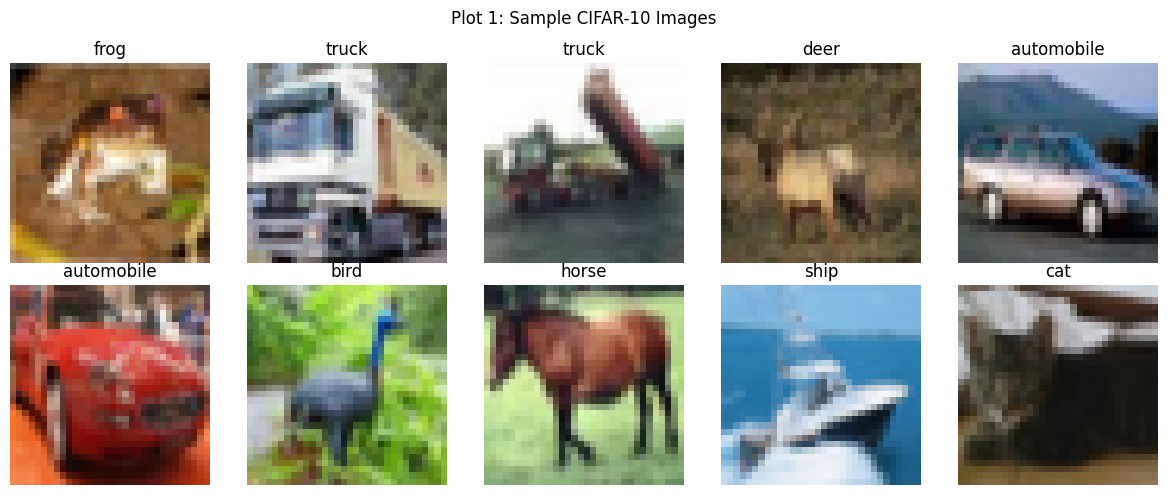

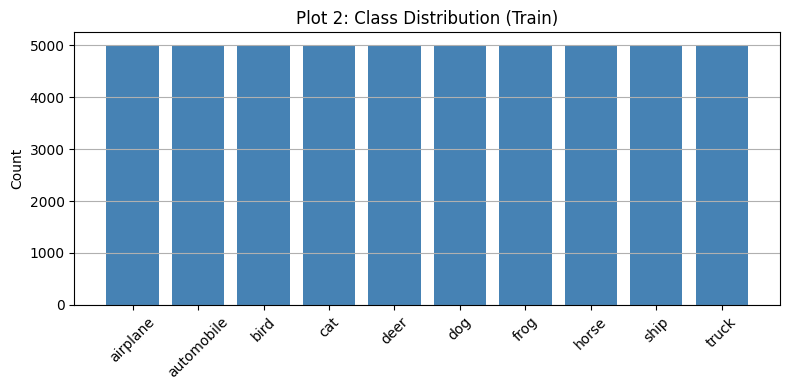

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train:", x_train.shape, "Test:", x_test.shape, "Classes:", len(class_names))

# Plot 1 — ten sample images
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i]); plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle('Plot 1: Sample CIFAR-10 Images'); plt.tight_layout()
plt.savefig('plot1_samples.png', dpi=120); plt.show()

# Plot 2 — class distribution
plt.figure(figsize=(8,4))
plt.bar(class_names, np.bincount(y_train.flatten()), color='steelblue')
plt.xticks(rotation=45); plt.ylabel('Count')
plt.title('Plot 2: Class Distribution (Train)'); plt.grid(axis='y')
plt.tight_layout(); plt.savefig('plot2_class_dist.png', dpi=120); plt.show()

# Normalize to [0,1]
x_train_n = x_train.astype('float32') / 255.0
x_test_n  = x_test.astype('float32')  / 255.0
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh  = tf.keras.utils.to_categorical(y_test, 10)


Kernel 3x3 (same, stride 1): output = 32
Kernel 5x5 (same, stride 1): output = 32
Kernel 7x7 (same, stride 1): output = 32


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


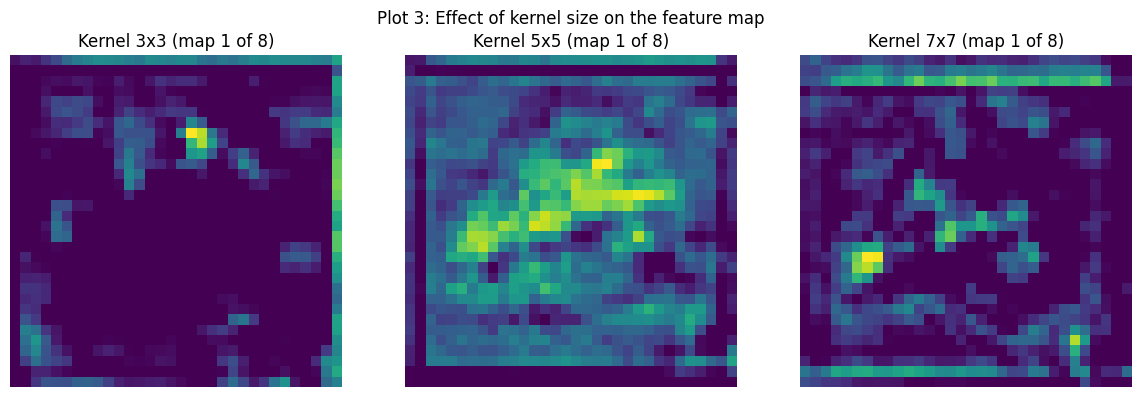

In [3]:
def conv_output(N, F, P, S): return (N - F + 2*P)//S + 1
for F in [3,5,7]:
    print(f"Kernel {F}x{F} (same, stride 1): output = {conv_output(32,F, F//2, 1)}")

# Visual feature-map comparison
sample = x_train_n[0:1]
fig, axes = plt.subplots(1,3, figsize=(12,4))
for ax, F in zip(axes, [3,5,7]):
    model = models.Sequential([
        layers.Conv2D(8, (F,F), padding='same', activation='relu',
                      input_shape=(32,32,3))
    ])
    fm = model.predict(sample, verbose=0)[0]
    ax.imshow(fm[:,:,0], cmap='viridis')
    ax.set_title(f'Kernel {F}x{F} (map 1 of 8)')
    ax.axis('off')
plt.suptitle('Plot 3: Effect of kernel size on the feature map')
plt.tight_layout(); plt.savefig('plot3_kernel_sizes.png', dpi=120); plt.show()


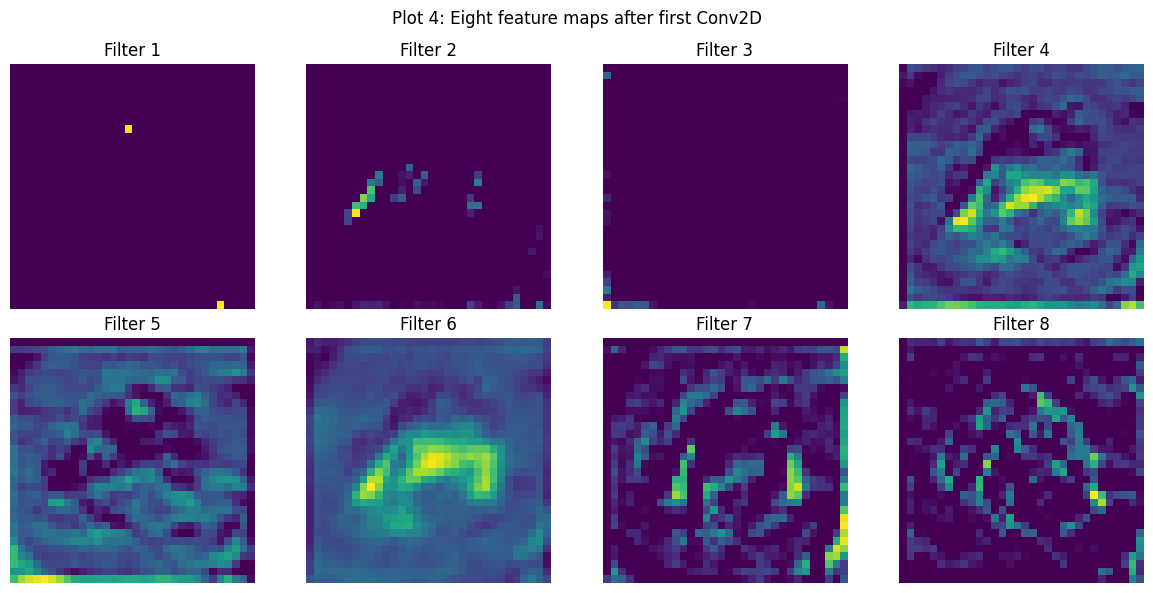

In [4]:
first_conv = models.Sequential([
    layers.Conv2D(8, (3,3), padding='same', activation='relu',
                  input_shape=(32,32,3))
])
fm = first_conv.predict(x_train_n[0:1], verbose=0)[0]  # (32,32,8)
plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1); plt.imshow(fm[:,:,i], cmap='viridis')
    plt.title(f'Filter {i+1}'); plt.axis('off')
plt.suptitle('Plot 4: Eight feature maps after first Conv2D')
plt.tight_layout(); plt.savefig('plot4_feature_maps.png', dpi=120); plt.show()



=== Pooling: max ===
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5037 - loss: 1.3882 - val_accuracy: 0.6022 - val_loss: 1.1190
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6470 - loss: 1.0109 - val_accuracy: 0.6540 - val_loss: 0.9861
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6953 - loss: 0.8701 - val_accuracy: 0.6810 - val_loss: 0.9296
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7356 - loss: 0.7629 - val_accuracy: 0.6872 - val_loss: 0.9160
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7685 - loss: 0.6688 - val_accuracy: 0.6872 - val_loss: 0.9545
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7992 - loss: 0.5799 - val_accuracy: 0.6822 - val_loss: 0.9911
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8260 - loss: 0.5008 - val_accuracy: 0.6760 - val_loss: 1.0790

=== Pooling: avg ===
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s

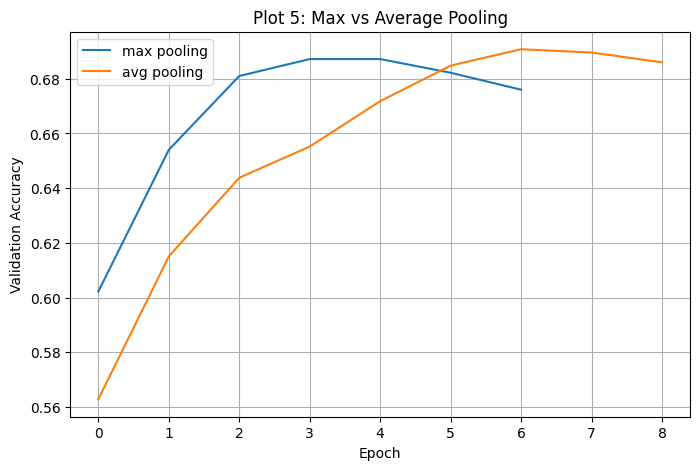

In [5]:
def build_cnn(pool='max', filters=32, kernel=3, extra_dense=128):
    P = layers.MaxPooling2D if pool=='max' else layers.AveragePooling2D
    m = models.Sequential([
        layers.Conv2D(filters,(kernel,kernel),padding='same',activation='relu',
                      input_shape=(32,32,3)),
        P((2,2)),
        layers.Conv2D(filters*2,(kernel,kernel),padding='same',activation='relu'),
        P((2,2)),
        layers.Flatten(),
        layers.Dense(extra_dense, activation='relu'),
        layers.Dense(10, activation='softmax'),
    ])
    m.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

histories = {}
for pool in ['max','avg']:
    print(f"\n=== Pooling: {pool} ===")
    tf.keras.backend.clear_session()
    m = build_cnn(pool=pool)
    t0 = time.time()
    h = m.fit(x_train_n, y_train_oh, validation_split=0.1,
              epochs=10, batch_size=32, verbose=1,
              callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)])
    histories[pool] = (h.history, time.time()-t0)

plt.figure(figsize=(8,5))
for pool,(h,_) in histories.items():
    plt.plot(h['val_accuracy'], label=f'{pool} pooling')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.title('Plot 5: Max vs Average Pooling'); plt.legend(); plt.grid(True)
plt.savefig('plot5_pooling.png', dpi=120); plt.show()


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.4877 - loss: 1.4351 - val_accuracy: 0.5814 - val_loss: 1.1671
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6289 - loss: 1.0633 - val_accuracy: 0.6508 - val_loss: 1.0069
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6802 - loss: 0.9193 - val_accuracy: 0.6754 - val_loss: 0.9400
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7169 - loss: 0.8224 - val_accuracy: 0.6928 - val_loss: 0.9016
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7440 - loss: 0.7426 - val_accuracy: 0.6984 - val_loss: 0.9026
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7700 - loss: 0.6697 - val_accuracy: 0.6984 - val_loss: 0.9232
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7935 - loss: 0.6032 - val_accuracy: 0.6984 - val_loss: 0.9679
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8152 - loss: 0.5404 -

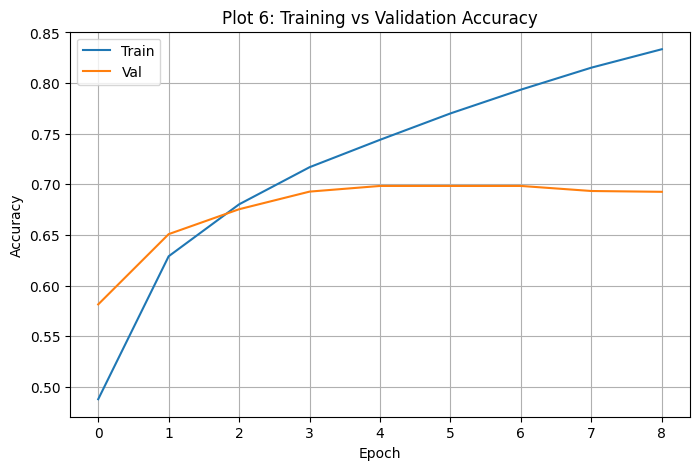

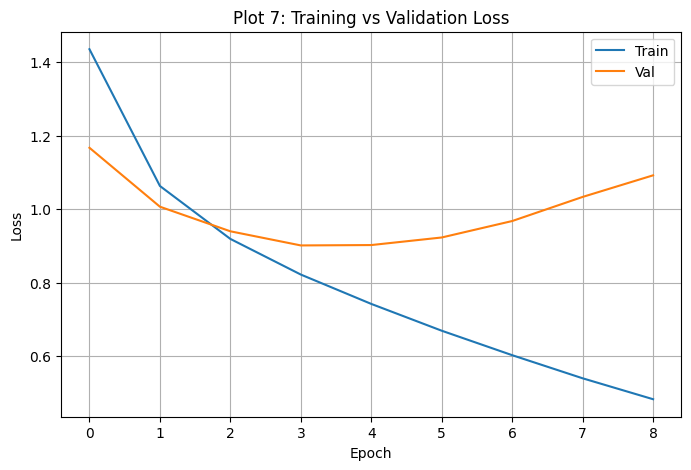

In [6]:
tf.keras.backend.clear_session()
model = build_cnn(pool='max', filters=32, kernel=3)
EPOCHS = 20
t0 = time.time()
history = model.fit(x_train_n, y_train_oh, validation_split=0.1,
                    epochs=EPOCHS, batch_size=32, verbose=1,
                    callbacks=[callbacks.EarlyStopping(patience=5,
                                                        restore_best_weights=True)])
train_time = time.time() - t0
print(f"Training time: {train_time:.1f} s")

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title('Plot 6: Training vs Validation Accuracy')
plt.legend(); plt.grid(True)
plt.savefig('plot6_acc.png', dpi=120); plt.show()

plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Plot 7: Training vs Validation Loss')
plt.legend(); plt.grid(True)
plt.savefig('plot7_loss.png', dpi=120); plt.show()


Test accuracy: 0.6812


Precision: 0.6817  Recall: 0.6812  F1: 0.6797
              precision    recall  f1-score   support

    airplane       0.72      0.74      0.73      1000
  automobile       0.81      0.71      0.76      1000
        bird       0.60      0.51      0.55      1000
         cat       0.51      0.51      0.51      1000
        deer       0.64      0.61      0.63      1000
         dog       0.59      0.60      0.59      1000
        frog       0.77      0.74      0.75      1000
       horse       0.72      0.78      0.75      1000
        ship       0.78      0.79      0.79      1000
       truck       0.68      0.83      0.75      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.68     10000
weighted avg       0.68      0.68      0.68     10000



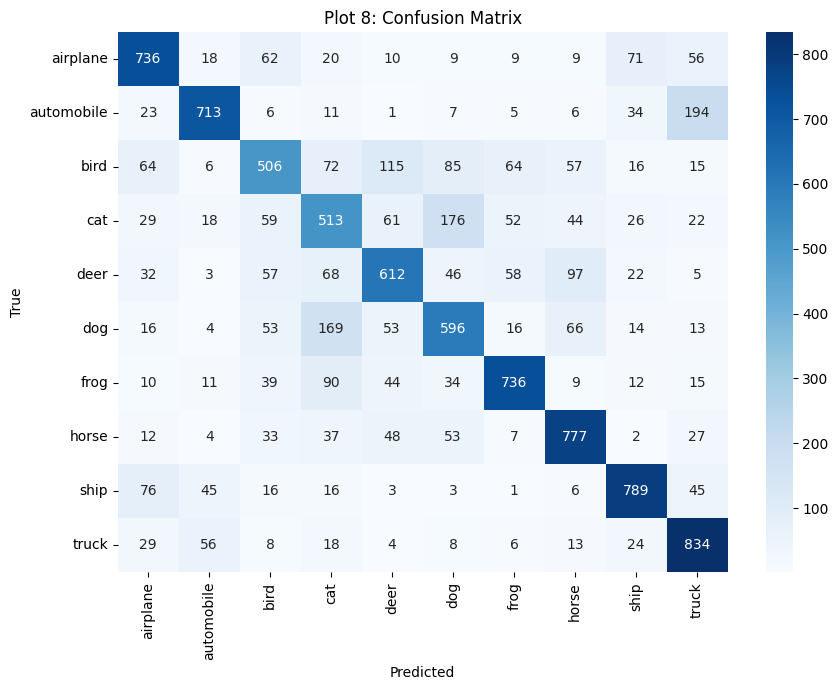

In [7]:
test_loss, test_acc = model.evaluate(x_test_n, y_test_oh, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

y_pred = np.argmax(model.predict(x_test_n, verbose=0), axis=1)
y_true = y_test.flatten()
prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred,
                                                    average='weighted', zero_division=0)
print(f"Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title('Plot 8: Confusion Matrix')
plt.tight_layout(); plt.savefig('plot8_confusion.png', dpi=120); plt.show()


Ex 1: 64x64, K=5, S=2, P=2 -> 32
Ex 2: (3*3*3+1)*64 = 1792


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


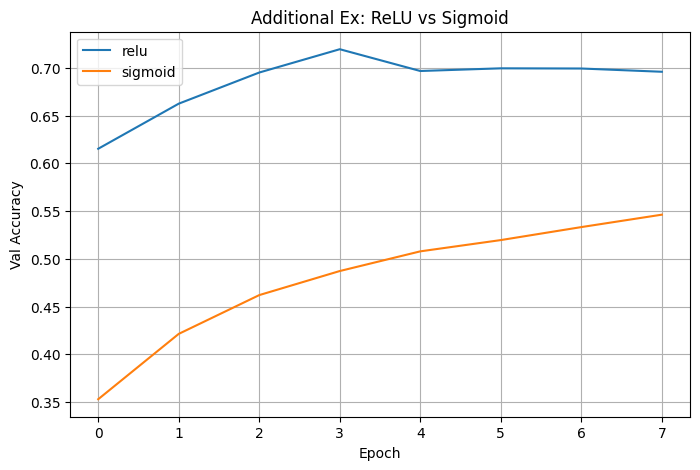

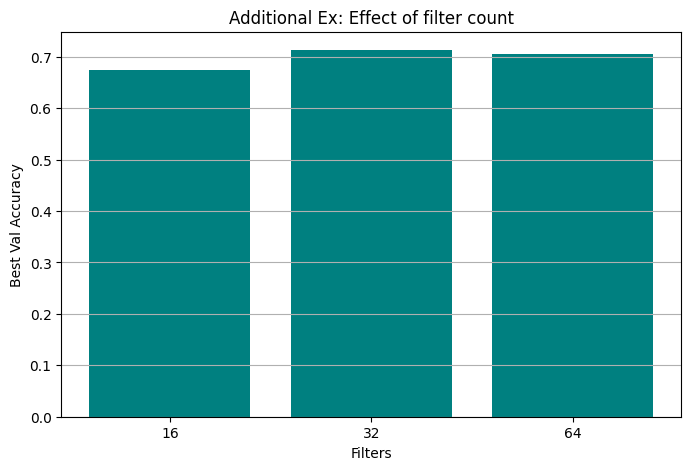

filters=16: best val acc=0.6744, params=268,650
filters=32: best val acc=0.7132, params=545,098
filters=64: best val acc=0.7052, params=1,125,642
DONE


In [8]:
# Ex 1 — output size for 64x64, kernel 5x5, stride 2, pad 2
print("Ex 1: 64x64, K=5, S=2, P=2 ->",
      (64 + 2*2 - 5)//2 + 1)                       # -> 32

# Ex 2 — trainable params of 64 filters, 3x3, RGB
print("Ex 2: (3*3*3+1)*64 =", (3*3*3+1)*64)        # -> 1792

# Ex 3 — ReLU vs Sigmoid quick run
def build_act(act):
    m = models.Sequential([
        layers.Conv2D(32,(3,3),padding='same',activation=act,input_shape=(32,32,3)),
        layers.MaxPooling2D(2),
        layers.Conv2D(64,(3,3),padding='same',activation=act),
        layers.MaxPooling2D(2),
        layers.Flatten(), layers.Dense(128,activation=act),
        layers.Dense(10,activation='softmax'),
    ])
    m.compile('adam','categorical_crossentropy',metrics=['accuracy'])
    return m

act_hist = {}
for act in ['relu','sigmoid']:
    tf.keras.backend.clear_session()
    m = build_act(act)
    h = m.fit(x_train_n, y_train_oh, validation_split=0.1,
              epochs=8, batch_size=32, verbose=0)
    act_hist[act] = h.history
plt.figure(figsize=(8,5))
for act,h in act_hist.items():
    plt.plot(h['val_accuracy'], label=act)
plt.title('Additional Ex: ReLU vs Sigmoid'); plt.xlabel('Epoch')
plt.ylabel('Val Accuracy'); plt.legend(); plt.grid(True)
plt.savefig('plot9_relu_vs_sigmoid.png', dpi=120); plt.show()

# Ex 4 — Avg pooling already covered in TASK 5 (Plot 5)

# Ex 5 — Filters 16 -> 64
plt.figure(figsize=(8,5))
filter_accs = {}
for f in [16, 32, 64]:
    tf.keras.backend.clear_session()
    m = build_cnn(filters=f, kernel=3)
    h = m.fit(x_train_n, y_train_oh, validation_split=0.1,
              epochs=6, batch_size=32, verbose=0)
    filter_accs[f] = (max(h.history['val_accuracy']),
                      m.count_params())
plt.bar([str(k) for k in filter_accs],
        [v[0] for v in filter_accs.values()],
        color='teal')
plt.xlabel('Filters'); plt.ylabel('Best Val Accuracy')
plt.title('Additional Ex: Effect of filter count'); plt.grid(axis='y')
plt.savefig('plot10_filter_count.png', dpi=120); plt.show()
for k,v in filter_accs.items():
    print(f"filters={k}: best val acc={v[0]:.4f}, params={v[1]:,}")

print("DONE")

Ex1 – Convolution feature map:
 [[ 6.  8.]
 [12. 14.]]
Ex2 – Max-pooling output:
 [[8. 3.]
 [6. 9.]]
Ex3 – Trainable params (16 filters, 3x3, RGB): 448

Task 2 — Feature-map sizes for different kernels:
  Kernel 3x3 → feature map shape (32, 32, 8)
  Kernel 5x5 → feature map shape (32, 32, 8)
  Kernel 7x7 → feature map shape (32, 32, 8)

Task 5 — Pooling output sizes (input 32x32, pool 2x2):
  MaxPool: output shape = (16, 16, 3)
  AvgPool: output shape = (16, 16, 3)


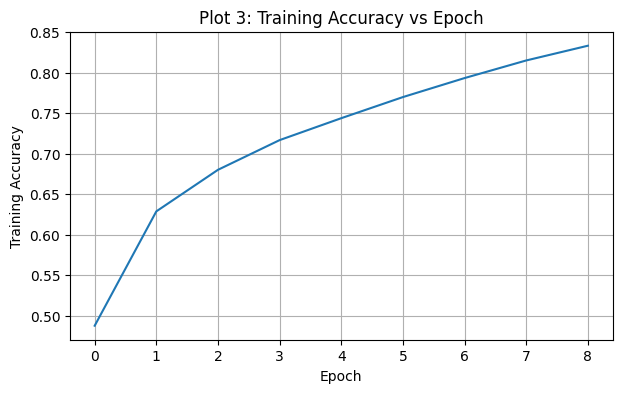

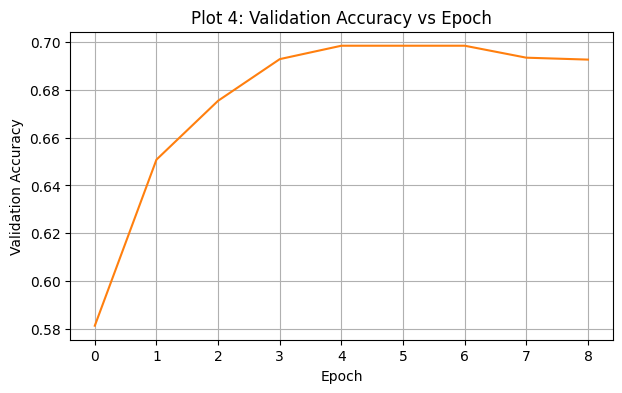

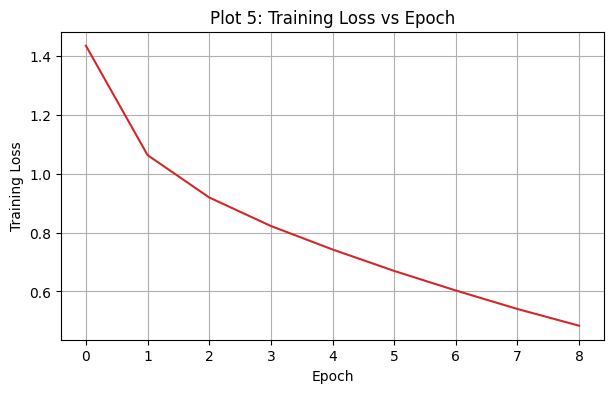

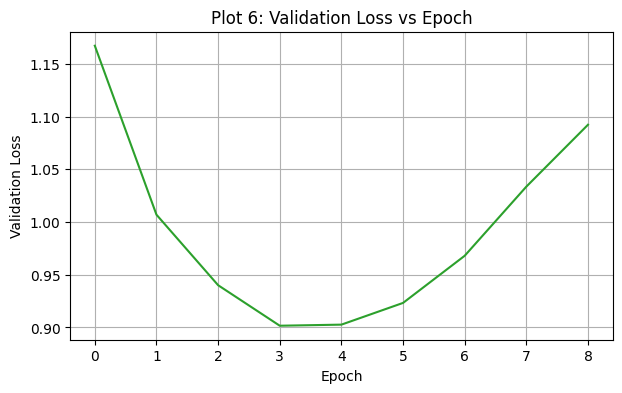

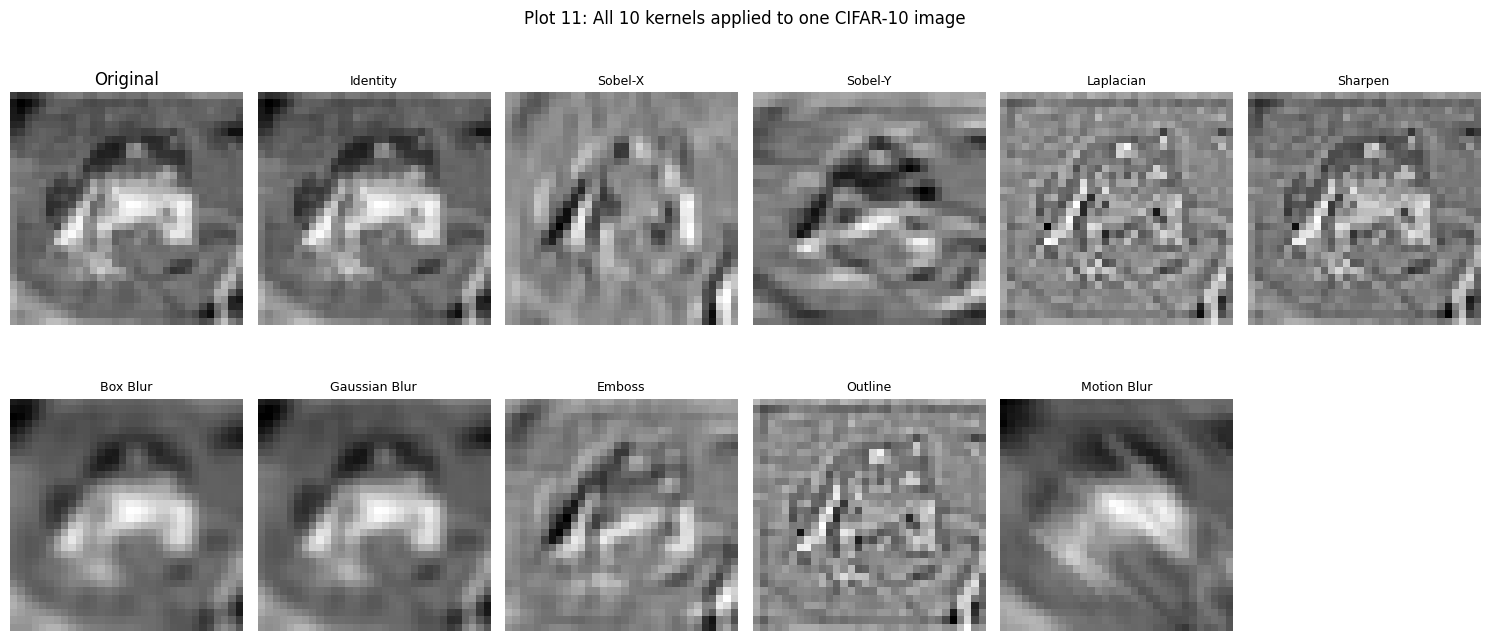

In [9]:
# ============================================================
# ADDENDUM 1 — Verify Numerical Examples 1, 2, 3
# ============================================================
import numpy as np, tensorflow as tf

# ---- Numerical Example 1: Convolution ----
X = np.array([[1,2,3],[4,5,6],[7,8,9]], dtype=np.float32)[None,:,:,None]  # (1,3,3,1)
K = np.array([[1,0],[0,1]], dtype=np.float32)[:,:,None,None]               # (2,2,1,1)
Y = tf.nn.conv2d(X, K, strides=1, padding='VALID').numpy()[0,:,:,0]
print("Ex1 – Convolution feature map:\n", Y)
# Expected: [[6, 8], [12, 14]]

# ---- Numerical Example 2: Max Pooling ----
F = np.array([[1,5,2,3],[7,8,1,0],[4,6,9,5],[2,3,1,8]], dtype=np.float32)[None,:,:,None]
P = tf.nn.max_pool2d(F, ksize=2, strides=2, padding='VALID').numpy()[0,:,:,0]
print("Ex2 – Max-pooling output:\n", P)
# Expected: [[8, 3], [6, 9]]

# ---- Numerical Example 3: Parameter count ----
layer = tf.keras.layers.Conv2D(16, (3,3), input_shape=(32,32,3))
layer.build((None,32,32,3))
print("Ex3 – Trainable params (16 filters, 3x3, RGB):", layer.count_params())
# Expected: 448

# ============================================================
# ADDENDUM 2 — Task 2: Record actual feature-map sizes
# ============================================================
print("\nTask 2 — Feature-map sizes for different kernels:")
for F in [3,5,7]:
    m = tf.keras.Sequential([
        tf.keras.layers.Conv2D(8,(F,F),padding='same',
                               activation='relu',input_shape=(32,32,3))
    ])
    out = m.compute_output_shape((None,32,32,3))
    print(f"  Kernel {F}x{F} → feature map shape {out[1:]}")

# ============================================================
# ADDENDUM 3 — Task 5: Pooling output sizes
# ============================================================
print("\nTask 5 — Pooling output sizes (input 32x32, pool 2x2):")
inp = tf.zeros((1,32,32,3))
for name, layer in [('MaxPool', tf.keras.layers.MaxPooling2D(2)),
                    ('AvgPool', tf.keras.layers.AveragePooling2D(2))]:
    out = layer(inp)
    print(f"  {name}: output shape = {tuple(out.shape[1:])}")

# ============================================================
# ADDENDUM 4 — Split accuracy/loss into 4 separate plots
# ============================================================
# Training Accuracy (Plot 3)
plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], color='tab:blue')
plt.xlabel('Epoch'); plt.ylabel('Training Accuracy')
plt.title('Plot 3: Training Accuracy vs Epoch')
plt.grid(True); plt.savefig('plot3_train_acc.png', dpi=120); plt.show()

# Validation Accuracy (Plot 4)
plt.figure(figsize=(7,4))
plt.plot(history.history['val_accuracy'], color='tab:orange')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.title('Plot 4: Validation Accuracy vs Epoch')
plt.grid(True); plt.savefig('plot4_val_acc.png', dpi=120); plt.show()

# Training Loss (Plot 5)
plt.figure(figsize=(7,4))
plt.plot(history.history['loss'], color='tab:red')
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 5: Training Loss vs Epoch')
plt.grid(True); plt.savefig('plot5_train_loss.png', dpi=120); plt.show()

# Validation Loss (Plot 6)
plt.figure(figsize=(7,4))
plt.plot(history.history['val_loss'], color='tab:green')
plt.xlabel('Epoch'); plt.ylabel('Validation Loss')
plt.title('Plot 6: Validation Loss vs Epoch')
plt.grid(True); plt.savefig('plot6_val_loss.png', dpi=120); plt.show()

# ============================================================
# ADDENDUM 5 — Section 3.1: Demonstrate all 10 kernels
# ============================================================
import cv2
from scipy.signal import convolve2d

# Use a colour sample from CIFAR-10
sample_gray = np.dot(x_train_n[0], [0.299, 0.587, 0.114])   # 32x32 grayscale

kernels = {
    'Identity':      np.array([[0,0,0],[0,1,0],[0,0,0]], float),
    'Sobel-X':       np.array([[-1,0,1],[-2,0,2],[-1,0,1]], float),
    'Sobel-Y':       np.array([[-1,-2,-1],[0,0,0],[1,2,1]], float),
    'Laplacian':     np.array([[0,-1,0],[-1,4,-1],[0,-1,0]], float),
    'Sharpen':       np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], float),
    'Box Blur':      np.ones((3,3))/9.0,
    'Gaussian Blur': np.array([[1,2,1],[2,4,2],[1,2,1]])/16.0,
    'Emboss':        np.array([[-2,-1,0],[-1,1,1],[0,1,2]], float),
    'Outline':       np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]], float),
    'Motion Blur':   np.eye(5, dtype=float)/5.0,
}

# Pad to preserve size for 3x3 and 5x5 (only visual aid)
plt.figure(figsize=(15,7))
plt.subplot(2,6,1)
plt.imshow(sample_gray, cmap='gray'); plt.title('Original'); plt.axis('off')
for i, (name, k) in enumerate(kernels.items()):
    conv = convolve2d(sample_gray, k, mode='same', boundary='symm')
    plt.subplot(2,6,i+2)
    plt.imshow(conv, cmap='gray'); plt.title(name, fontsize=9); plt.axis('off')
plt.suptitle('Plot 11: All 10 kernels applied to one CIFAR-10 image')
plt.tight_layout(); plt.savefig('plot11_all_kernels.png', dpi=120); plt.show()